In [ ]:
!pip install reverse_geocoder pycountry_convert pandas timm geopandas geodatasets
import os
import pandas as pd
import numpy as np
import math
import timm
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import reverse_geocoder as rg
import pycountry_convert as pc
import matplotlib.pyplot as plt
import geodatasets

from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
from torch.utils.data import Dataset
from tqdm import tqdm
from collections import defaultdict
from tqdm import tqdm




# Setup and Data Processing

In [ ]:
CONTINENT_MAP = {
    'AF': 0, 'NA': 1, 'SA': 2, 'AS': 3, 'EU': 4, 'OC': 5, 'AN': 6
}

def get_labels(lat, lon):
    """
    Returns both Continent ID and XYZ coordinates
    """
    try:
        results = rg.search((lat, lon), mode=1)
        country_code = results[0]['cc']
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        cont_id = CONTINENT_MAP.get(continent_code, -1)
    except:
        cont_id = -1 # Unknown

    lat_rad = math.radians(lat)
    lon_rad = math.radians(lon)
    x = math.cos(lat_rad) * math.cos(lon_rad)
    y = math.cos(lat_rad) * math.sin(lon_rad)
    z = math.sin(lat_rad)
    # This needs to be done as -180 and +180 looks very far, but in reality is very close
    # If we do not convert it to this spherical coordinate scale, the loss will misbehave.


    # We return the continent aswell as spherical coordinates.
    # The plan is to first classify the image into a continent before then locating the
    # precise coordinates. This is done so that the model doesn't try to "average out"
    # similar locations which are far apart. i.e Canadian forest vs Swedish forest
    return cont_id, x, y, z

In [ ]:
def process_folder(folder_path, output_csv_name, output_csv_dir):
    print(f"--- Processing {output_csv_name} ---")

    if not os.path.exists(folder_path):
        print(f"ERROR: Folder not found: {folder_path}")
        return

    data_list = []
    valid_extensions = ('.jpg', '.jpeg', '.png')

    files = [f for f in os.listdir(folder_path) if f.endswith(valid_extensions)]

    for filename in tqdm(files):
        try:
            name_clean = os.path.splitext(filename)[0]
            parts = name_clean.split('_')

            lon = float(parts[0])
            lat = float(parts[1])

            cont_id, x, y, z = get_labels(lat, lon)

            data_list.append({
                'filename': filename,
                'lat': lat,
                'lon': lon,
                'continent_id': cont_id,
                'target_x': x,
                'target_y': y,
                'target_z': z
            })

        except Exception as e:
            print(f"Skipping {filename}: {e}")

    df = pd.DataFrame(data_list)
    # Remove all data where the continent is unknown
    df = df[df['continent_id'] != -1]


    save_path = os.path.join(output_csv_dir, output_csv_name)
    df.to_csv(save_path, index=False)
    print(f"Saved {len(df)} entries to {save_path}\n")

In [ ]:
BASE_DATA_DIR = '/csc413/data'

TRAIN_DIR = os.path.join(BASE_DATA_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DATA_DIR, 'test')
VAL_DIR   = os.path.join(BASE_DATA_DIR, 'val')

process_folder(TRAIN_DIR, 'train_labels.csv', BASE_DATA_DIR)
process_folder(VAL_DIR,   'val_labels.csv', BASE_DATA_DIR)
process_folder(TEST_DIR,  'test_labels.csv', BASE_DATA_DIR)

--- Processing train_labels.csv ---


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26713/26713 [00:00<00:00, 48625.06it/s]


Saved 26539 entries to /csc413/data/train_labels.csv

--- Processing val_labels.csv ---


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7746/7746 [00:00<00:00, 47735.94it/s]

Saved 7686 entries to /csc413/data/val_labels.csv

--- Processing test_labels.csv ---



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3948/3948 [00:00<00:00, 51916.12it/s]

Saved 3921 entries to /csc413/data/test_labels.csv



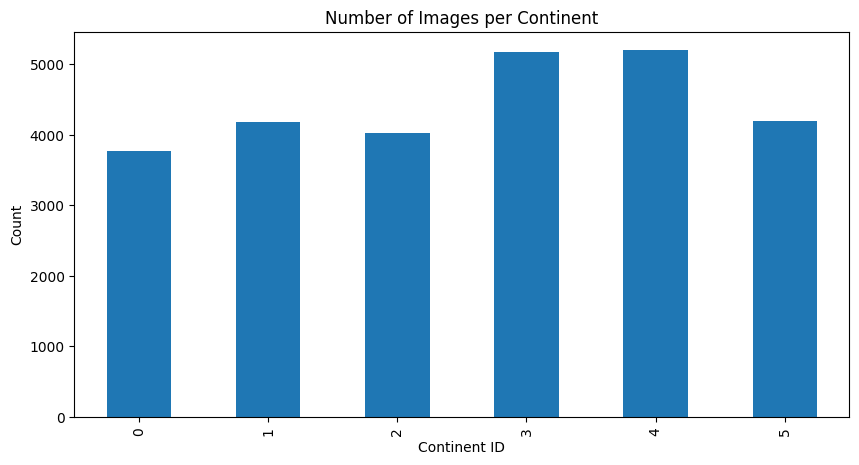

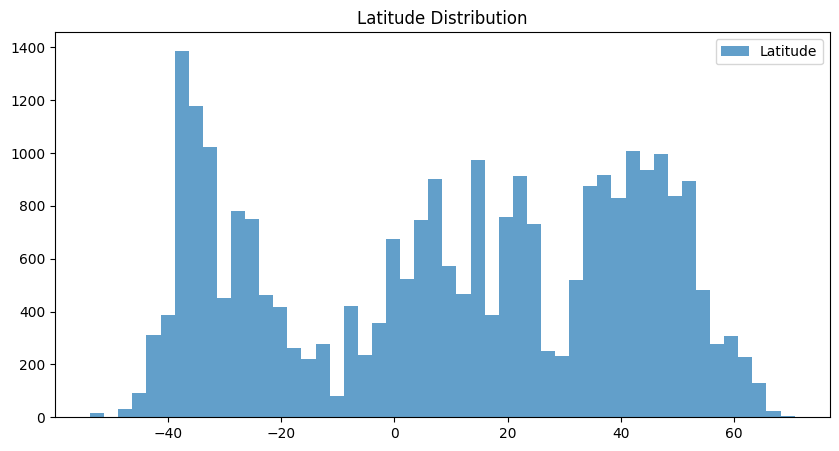

In [ ]:

df = pd.read_csv('/csc413/data/train_labels.csv')

plt.figure(figsize=(10,5))
df['continent_id'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Images per Continent")
plt.xlabel("Continent ID")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,5))
plt.hist(df['lat'], bins=50, alpha=0.7, label='Latitude')
plt.title("Latitude Distribution")
plt.legend()
plt.show()

In [ ]:
class GeoguessrDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform

        csv_name = f"{split}_labels.csv"
        csv_path = os.path.join(root_dir, csv_name)

        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Could not find {csv_name} in {root_dir}")

        self.df = pd.read_csv(csv_path)
        self.img_dir = os.path.join(root_dir, split)

        # Group rows by location (based on filename prefix: long_lat)
        self.grouped_data = defaultdict(list)
        for _, row in self.df.iterrows():
            filename = row['filename']
            # Format: longitude_latitude_orientation.jpg
            parts = filename.split('_')
            if len(parts) >= 2:
                key = f"{parts[0]}_{parts[1]}"
                self.grouped_data[key].append(row)

        self.keys = list(self.grouped_data.keys())

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        key = self.keys[idx]
        rows = self.grouped_data[key]

        # Ensure we always have 3 images (cycle if fewer)
        if len(rows) < 3:
            rows = rows * 3
        rows = rows[:3]

        images = []
        for row in rows:
            img_name = row['filename']
            img_path = os.path.join(self.img_dir, img_name)
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            images.append(image)

        # Stack images: [3, Channels, H, W]
        image_stack = torch.stack(images)

        # Get labels from the first image in the group (they are the same for the location)
        first_row = rows[0]
        continent_label = torch.tensor(first_row['continent_id'], dtype=torch.long)
        coord_label = torch.tensor(
            [first_row['target_x'], first_row['target_y'], first_row['target_z']],
            dtype=torch.float32
        )

        return image_stack, (continent_label, coord_label)

In [ ]:
import torch
import gc
import os
import timm
from torch.utils.data import DataLoader
from torchvision import transforms

if 'model' in globals(): del model
if 'optimizer' in globals(): del optimizer
torch.cuda.empty_cache()
gc.collect()

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.set_float32_matmul_precision('high')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {torch.cuda.get_device_name(0)}")

# 3. MODEL & DATA CONFIG
MODEL_NAME = 'eva02_large_patch14_448.mim_in22k_ft_in22k_in1k'
data_config = timm.data.resolve_data_config({}, model=MODEL_NAME)
mean = data_config['mean']
std = data_config['std']

BATCH_SIZE = 32
ACCUMULATION_STEPS = 3
NUM_WORKERS = 16

transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.RandomResizedCrop(448, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15))
])

val_transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

ROOT_DIR = '/csc413/data'
train_data = GeoguessrDataset(ROOT_DIR, split='train', transform=transform)
val_data   = GeoguessrDataset(ROOT_DIR, split='val',   transform=val_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE,
                        num_workers=NUM_WORKERS, pin_memory=True)

Device: NVIDIA H100 80GB HBM3


This is a gated architecture which has a separate head for each continent. Once a specific continent is predicted, the continent-specific regression head predicts the coordinates.

In [ ]:
import torch.nn as nn

class GeoGuessrTimm(nn.Module):
    def __init__(self, num_continents=7):
        super().__init__()

        self.backbone = timm.create_model(
            MODEL_NAME,
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )

        if hasattr(self.backbone, 'set_grad_checkpointing'):
            self.backbone.set_grad_checkpointing(True)
        else:
            self.backbone.grad_checkpointing = True

        feature_dim = self.backbone.num_features # 1024

        # Continent Head
        self.continent_head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_continents)
        )

        # Coordinate Head
        self.coord_shared = nn.Sequential(
            nn.Linear(feature_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.3)
        )
        self.coord_out = nn.Linear(1024, num_continents * 3)

    def forward(self, x):
        b, v, c, h, w = x.shape

        # Flatten views: [B*3, C, H, W]
        x = x.reshape(b * v, c, h, w)

        # Backbone Forward
        # global_pool='avg' ensures output is [B*3, 1024]
        features = self.backbone(x)

        # Reshape to [B, 3, 1024]
        features = features.reshape(b, v, -1)

        # Mean pool over views
        features = torch.mean(features, dim=1)

        # Heads
        continent_logits = self.continent_head(features)

        coord_feats = self.coord_shared(features)
        raw_coords = self.coord_out(coord_feats)

        reshaped_coords = raw_coords.reshape(b, -1, 3)
        coordinates = torch.nn.functional.normalize(reshaped_coords, p=2, dim=2)

        return continent_logits, coordinates

#Training

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

model = GeoGuessrTimm(num_continents=7).to(device)

# Loss
criterion_continent = nn.CrossEntropyLoss()
class AngularLoss(nn.Module):
    def forward(self, preds, targets):
        cos_sim = (preds * targets).sum(dim=1).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        return torch.acos(cos_sim).mean()
criterion_coordinate = AngularLoss()

# Optimizer
optimizer = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-5},
    {'params': model.continent_head.parameters(), 'lr': 3e-4},
    {'params': model.coord_shared.parameters(), 'lr': 3e-4},
    {'params': model.coord_out.parameters(), 'lr': 3e-4}
], weight_decay=0.01)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
scaler = torch.amp.GradScaler('cuda')

lambda_coord = 400.0
num_epochs = 15

print(f"Starting training on {device}...")
print(f"Batch Size: {BATCH_SIZE} | Accumulation: {ACCUMULATION_STEPS} | Effective Batch: {BATCH_SIZE * ACCUMULATION_STEPS}")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

    for i, (imgs, (cont_labels, coord_labels)) in enumerate(loop):
        imgs = imgs.to(device, non_blocking=True)
        cont_labels = cont_labels.to(device, non_blocking=True)
        coord_labels = coord_labels.to(device, non_blocking=True)

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            cont_logits, all_coords = model(imgs)

            loss_cont = criterion_continent(cont_logits, cont_labels)

            batch_indices = torch.arange(imgs.size(0), device=device)
            pred_coords_active = all_coords[batch_indices, cont_labels]
            loss_coord = criterion_coordinate(pred_coords_active, coord_labels)

            loss = loss_cont + (lambda_coord * loss_coord)
            loss = loss / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item() * ACCUMULATION_STEPS * imgs.size(0)
        loop.set_postfix(loss=loss.item() * ACCUMULATION_STEPS)

    epoch_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    km_error_sum = 0.0
    correct_cont = 0
    total_samples = 0

    with torch.inference_mode():
        for imgs, (cont_labels, coord_labels) in val_loader:
            imgs = imgs.to(device)
            cont_labels = cont_labels.to(device)
            coord_labels = coord_labels.to(device)

            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                cont_logits, all_coords = model(imgs)

            _, pred_cont = torch.max(cont_logits, 1)
            correct_cont += (pred_cont == cont_labels).sum().item()

            batch_indices = torch.arange(imgs.size(0), device=device)
            pred_coords_final = all_coords[batch_indices, pred_cont]

            dot = (pred_coords_final * coord_labels).sum(dim=1).clamp(-1, 1)
            dist_km = 6371.0 * torch.acos(dot)
            km_error_sum += dist_km.sum().item()
            total_samples += imgs.size(0)

    val_mean_km = km_error_sum / total_samples
    val_acc = correct_cont / total_samples

    print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Cont Acc: {val_acc:.2%} | Mean KM: {val_mean_km:.2f}")

    if val_mean_km < best_val_score:
        best_val_score = val_mean_km
        torch.save(model.state_dict(), "best_geoguessr_h100.pt")
        print(">>> Saved Best Model")

    scheduler.step(val_mean_km)

Starting training on cuda...
Batch Size: 32 | Accumulation: 3 | Effective Batch: 96


Epoch [1/15]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 332/332 [11:20<00:00,  2.05s/it, loss=47.1]


Epoch 1 | Loss: 84.7055 | Cont Acc: 90.11% | Mean KM: 1375.71
>>> Saved Best Model


Epoch [2/15]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 332/332 [11:21<00:00,  2.05s/it, loss=45.3]


Epoch 2 | Loss: 45.4144 | Cont Acc: 93.24% | Mean KM: 1075.27
>>> Saved Best Model


...

Epoch 13 | Loss: 16.6456 | Cont Acc: 94.94% | Mean KM: 783.28


Epoch [14/15]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 332/332 [11:22<00:00,  2.05s/it, loss=12.9]


Epoch 14 | Loss: 15.9475 | Cont Acc: 95.72% | Mean KM: 728.57


Epoch [15/15]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 332/332 [11:21<00:00,  2.05s/it, loss=11.4]


Epoch 15 | Loss: 14.3232 | Cont Acc: 96.05% | Mean KM: 689.15
>>> Saved Best Model


# Model Evaluation

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    MSE_sum = 0
    km_sum = 0

    correct_cont_km_sum = 0.0  # km error only where continent is predicted correctly
    correct_cont_count  = 0    # number of such samples

    # New List to store ALL KM errors for median calculation
    all_km_errors = []

    with torch.no_grad():
        for imgs, (continent_labels, xyz_labels) in loader:
            imgs = imgs.to(device)
            continent_labels = continent_labels.to(device)
            xyz_labels = xyz_labels.to(device)

            logits, all_xyz_pred = model(imgs)
            _, preds = torch.max(logits, 1)

            batch_indices = torch.arange(imgs.size(0)).to(device)
            xyz_pred = all_xyz_pred[batch_indices, preds]

            total += continent_labels.size(0)
            correct += (preds == continent_labels).sum().item()

            MSE_sum += nn.functional.mse_loss(
                xyz_pred, xyz_labels, reduction="sum"
            ).item()

            # KM error for all samples in this batch
            km_errors = geo_distance_km(xyz_pred, xyz_labels)
            km_sum += km_errors.sum().item()

            # --- Store errors for median calculation ---
            all_km_errors.extend(km_errors.cpu().numpy())

            # KM error only when continent prediction is correct
            correct_mask = (preds == continent_labels)
            if correct_mask.any():
                km_correct = km_errors[correct_mask]
                correct_cont_km_sum += km_correct.sum().item()
                correct_cont_count += correct_mask.sum().item()

    median_km_error = np.median(all_km_errors) if all_km_errors else float("nan")

    return {
        "continent_accuracy": correct / total,
        "mse": MSE_sum / total,
        "km_error_mean": km_sum / total,
        "km_error_median": median_km_error,
        "km_error_if_continent_correct":
            (correct_cont_km_sum / correct_cont_count if correct_cont_count > 0 else float("nan"))
    }

In [ ]:
results = evaluate(model, val_loader)
print(results)

{'continent_accuracy': 0.960822722820764, 'mse': 0.07133580136155132, 'km_error_mean': 683.3666407142712, 'km_error_median': 251.18648, 'km_error_if_continent_correct': 366.67945157205656}


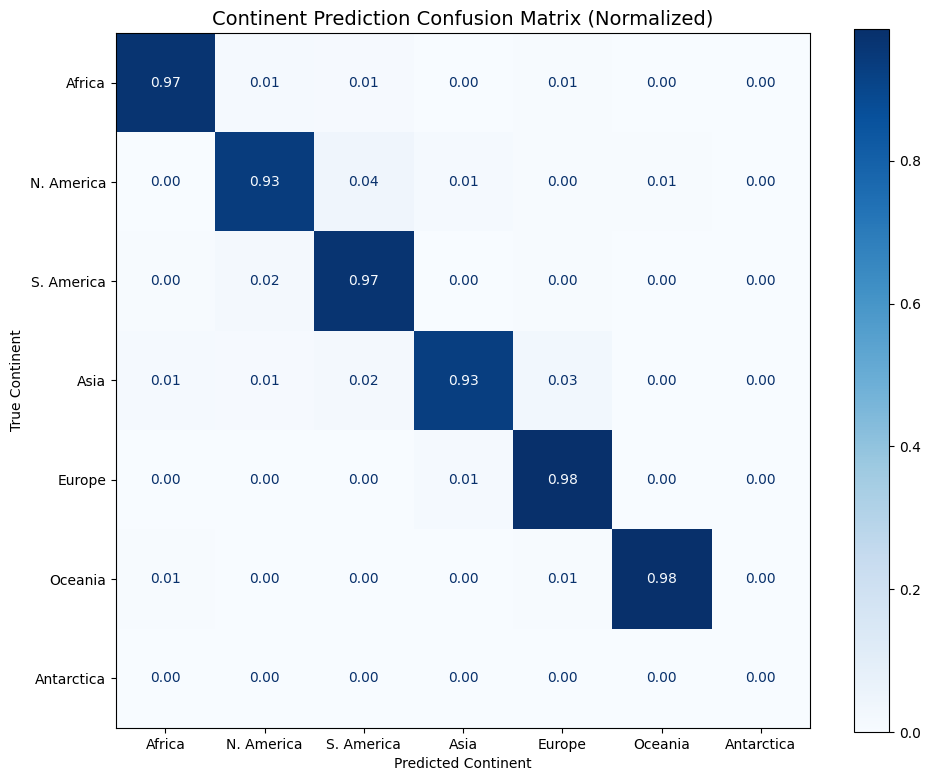

In [ ]:
def plot_continent_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    print("Collecting predictions...")
    with torch.inference_mode():
        for imgs, (cont_labels, coord_labels) in loader:
            imgs = imgs.to(device)

            logits, _ = model(imgs)

            _, preds = torch.max(logits, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(cont_labels.cpu().numpy())

    class_names = ['Africa', 'N. America', 'S. America', 'Asia', 'Europe', 'Oceania', 'Antarctica']

    cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=range(7),
        normalize='true'
    )


    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    disp.plot(cmap='Blues', ax=ax, values_format='.2f')

    plt.title("Continent Prediction Confusion Matrix (Normalized)", fontsize=14)
    plt.ylabel('True Continent')
    plt.xlabel('Predicted Continent')
    plt.tight_layout()
    plt.show()

plot_continent_confusion_matrix(model, val_loader, device)

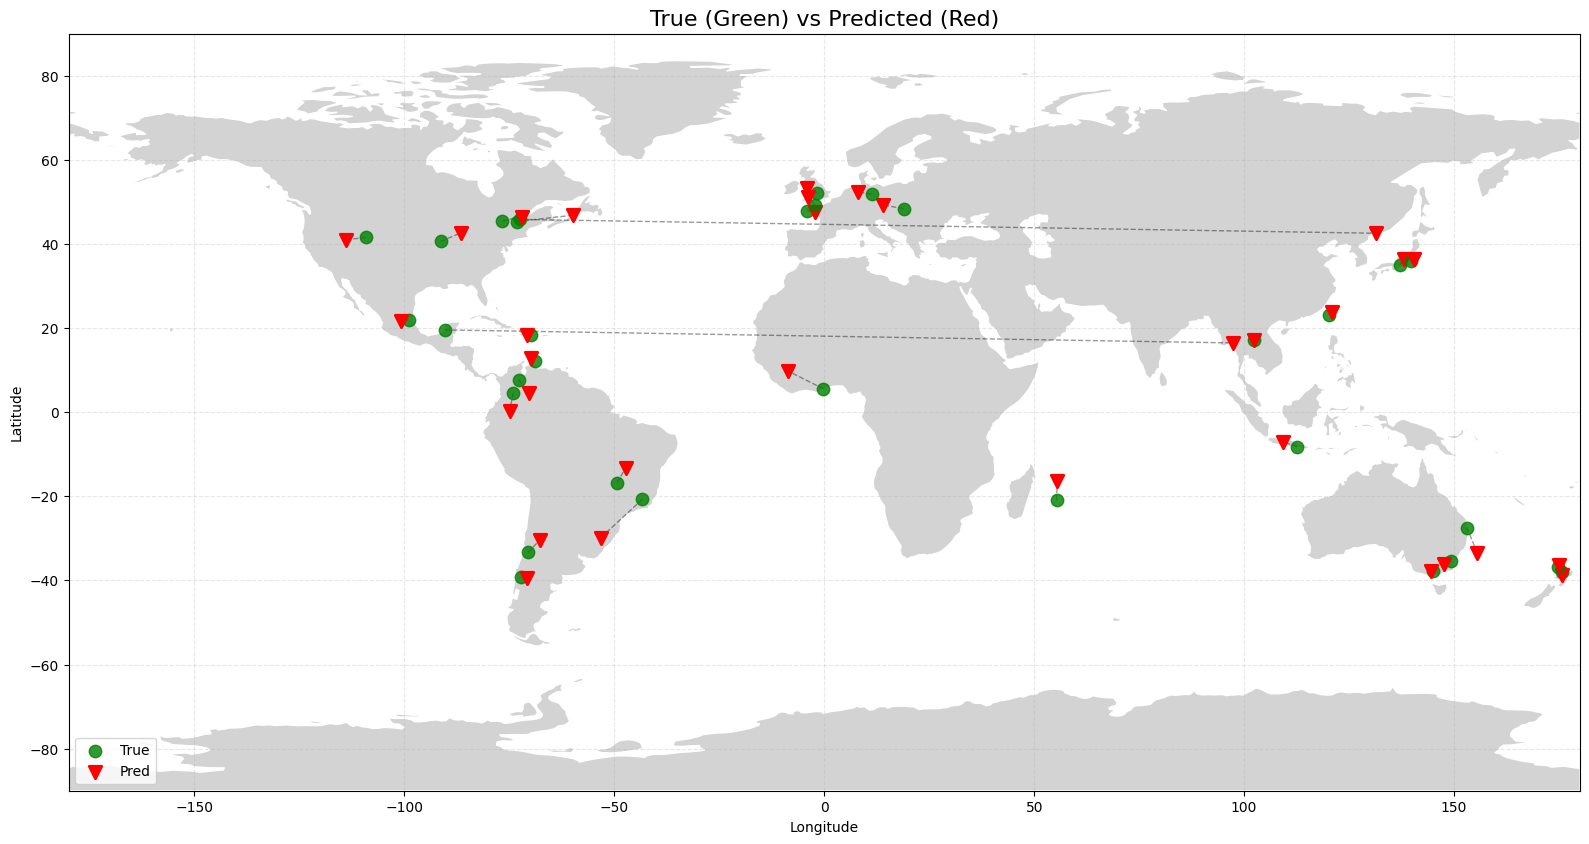

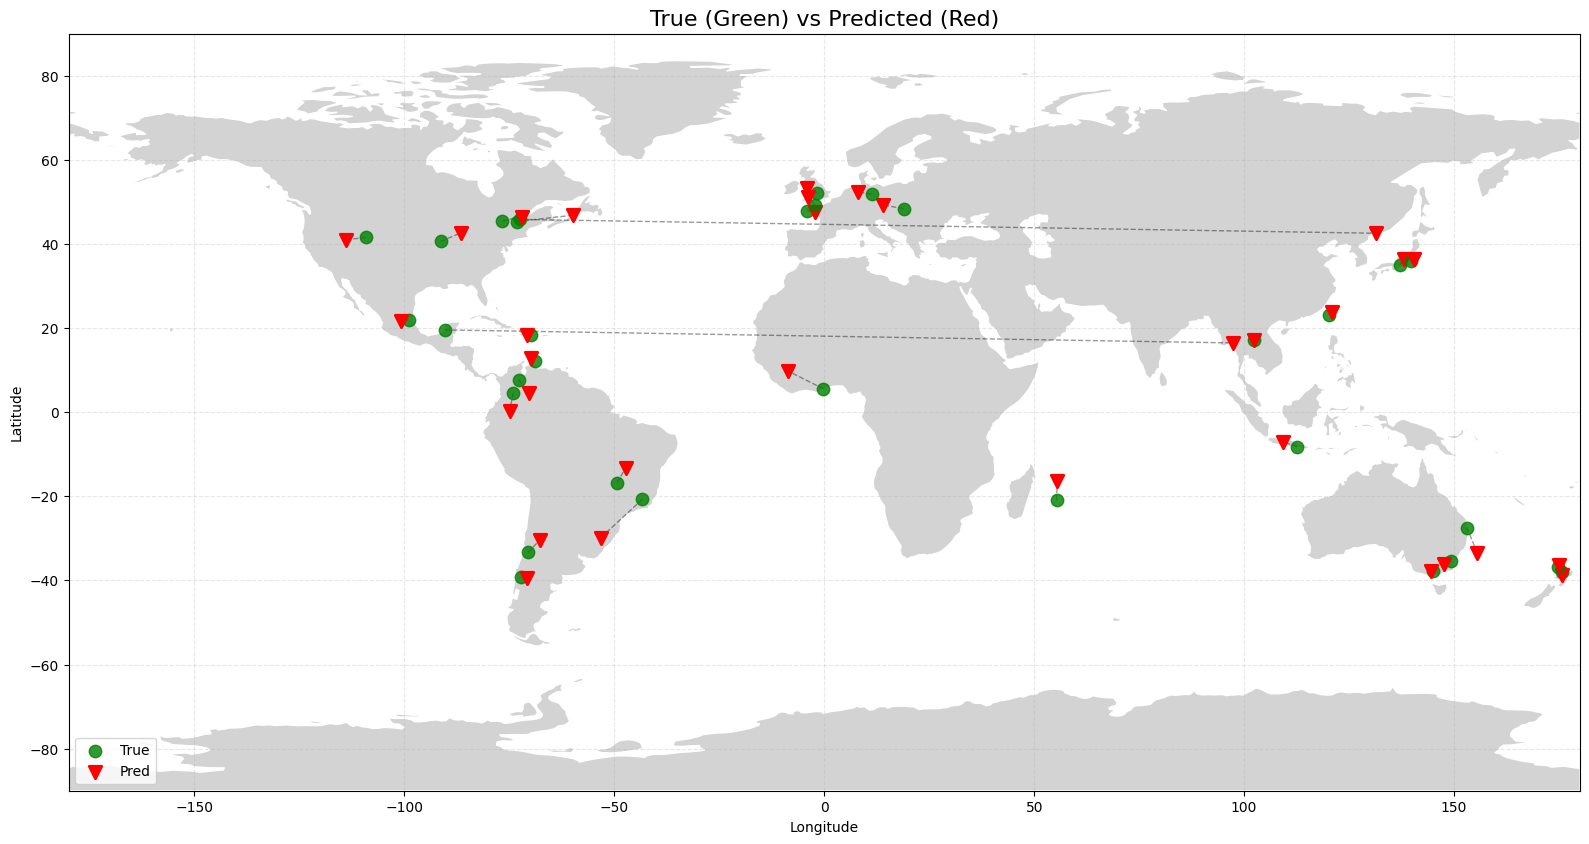

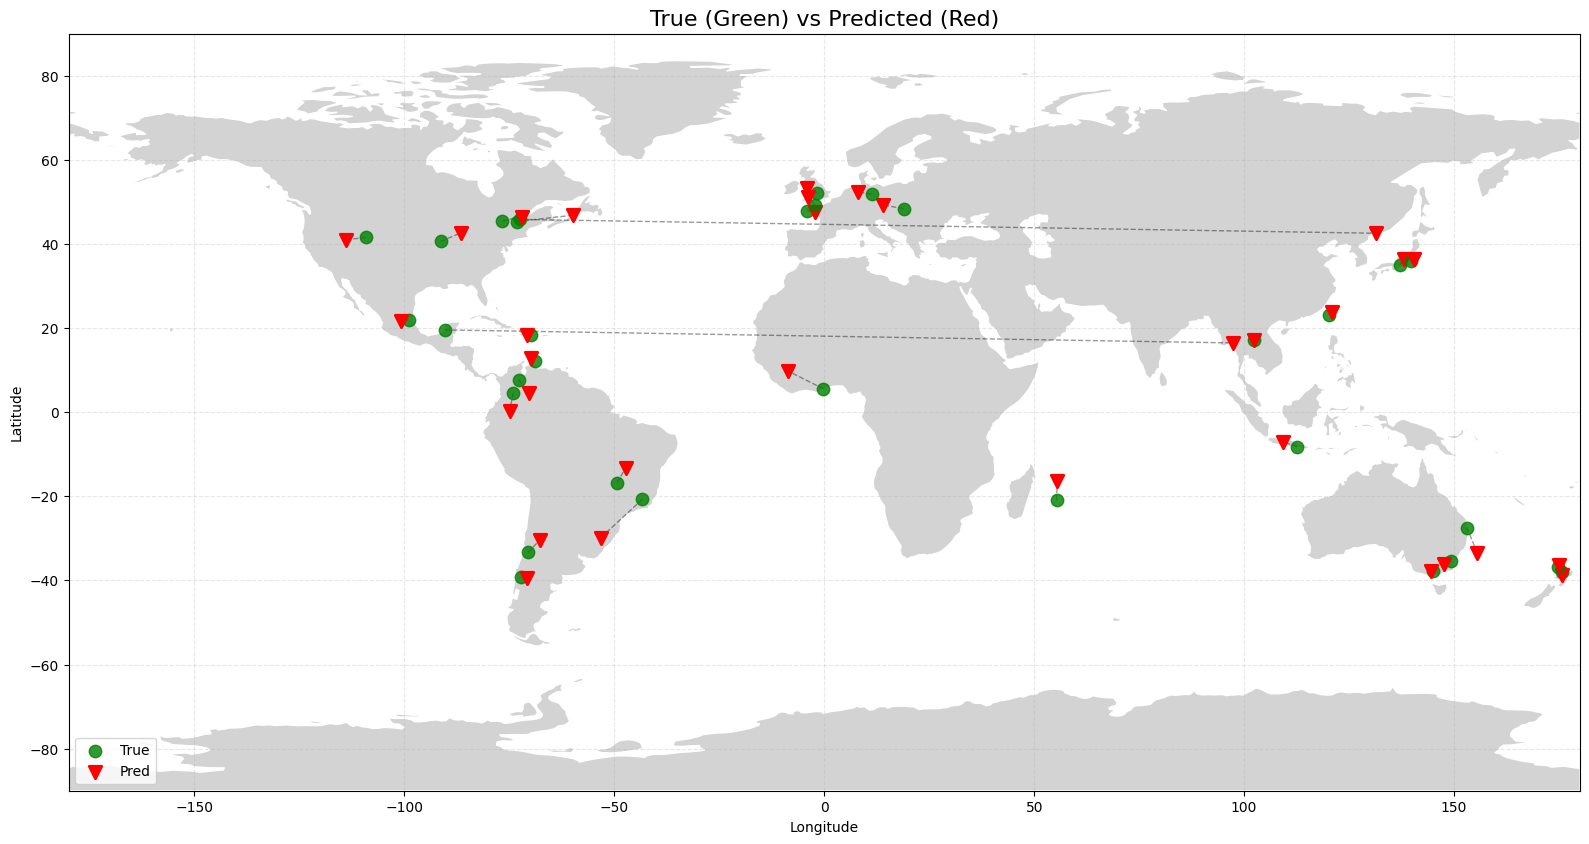

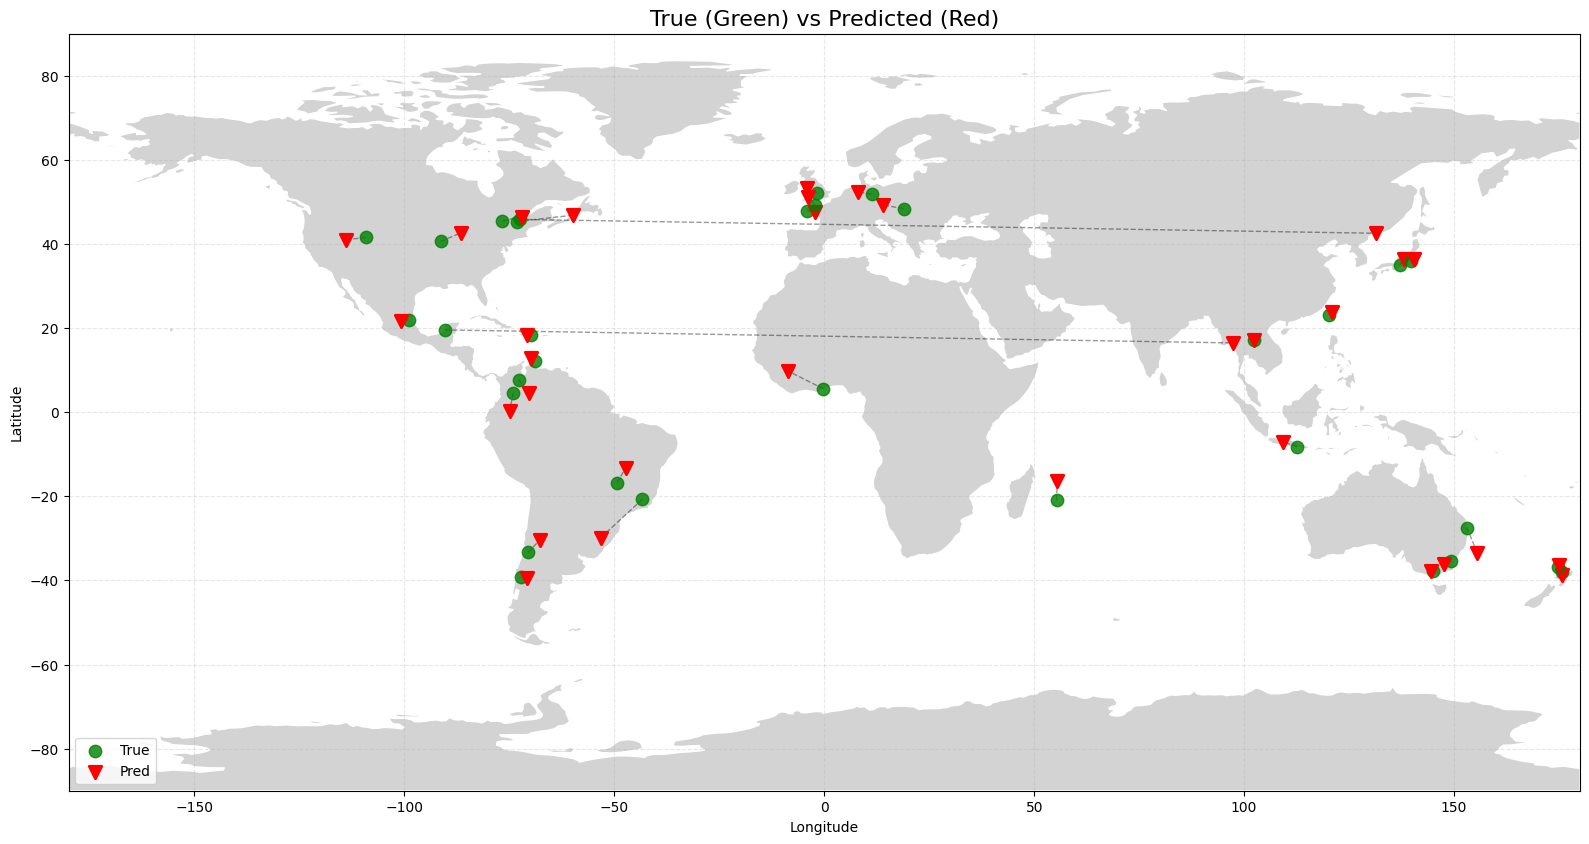

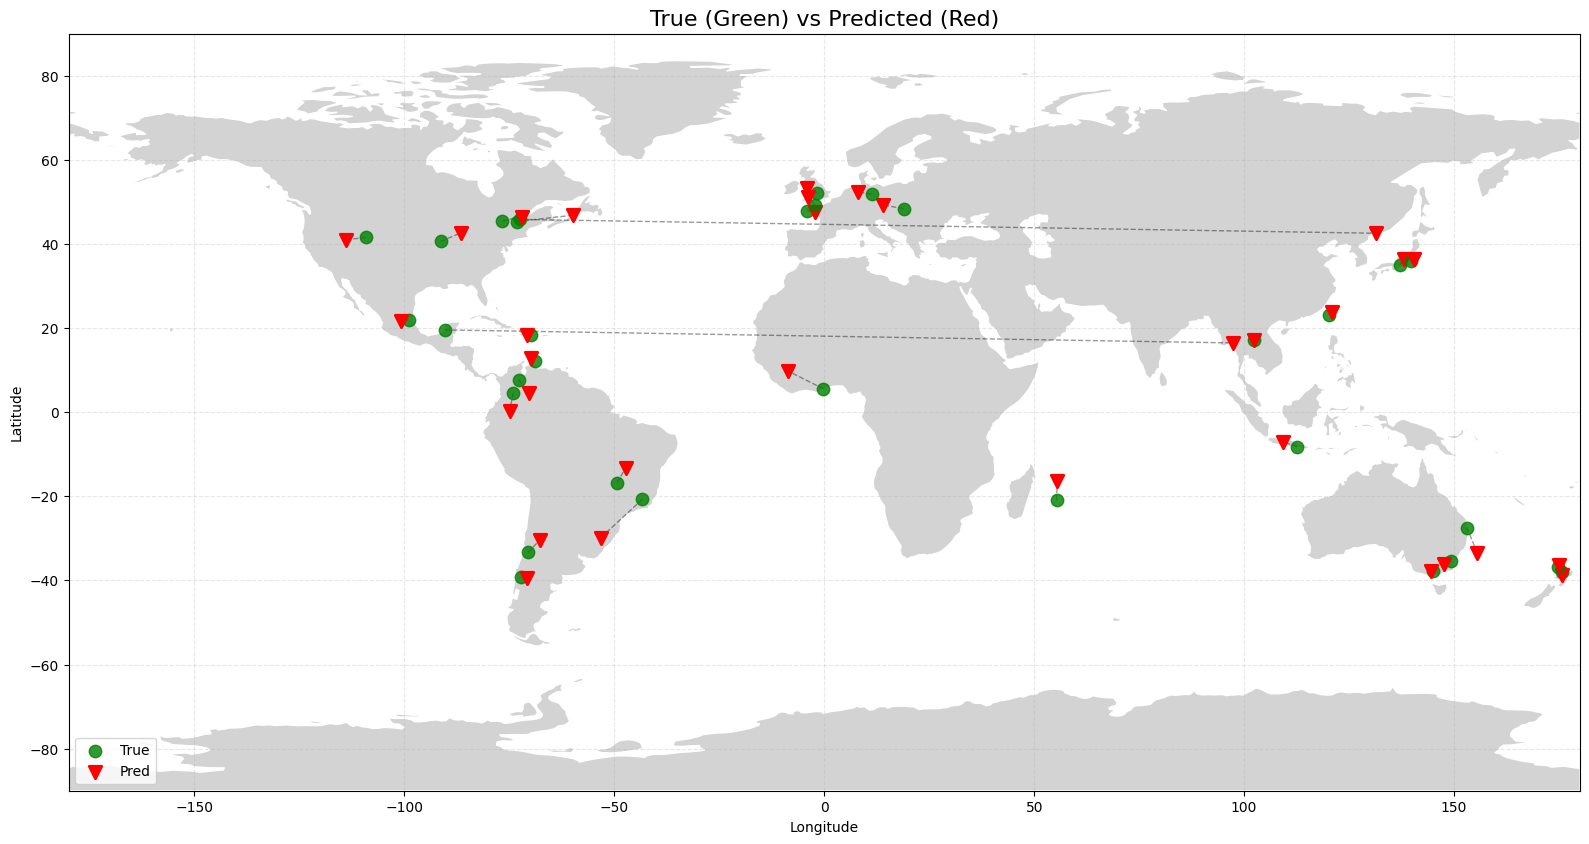

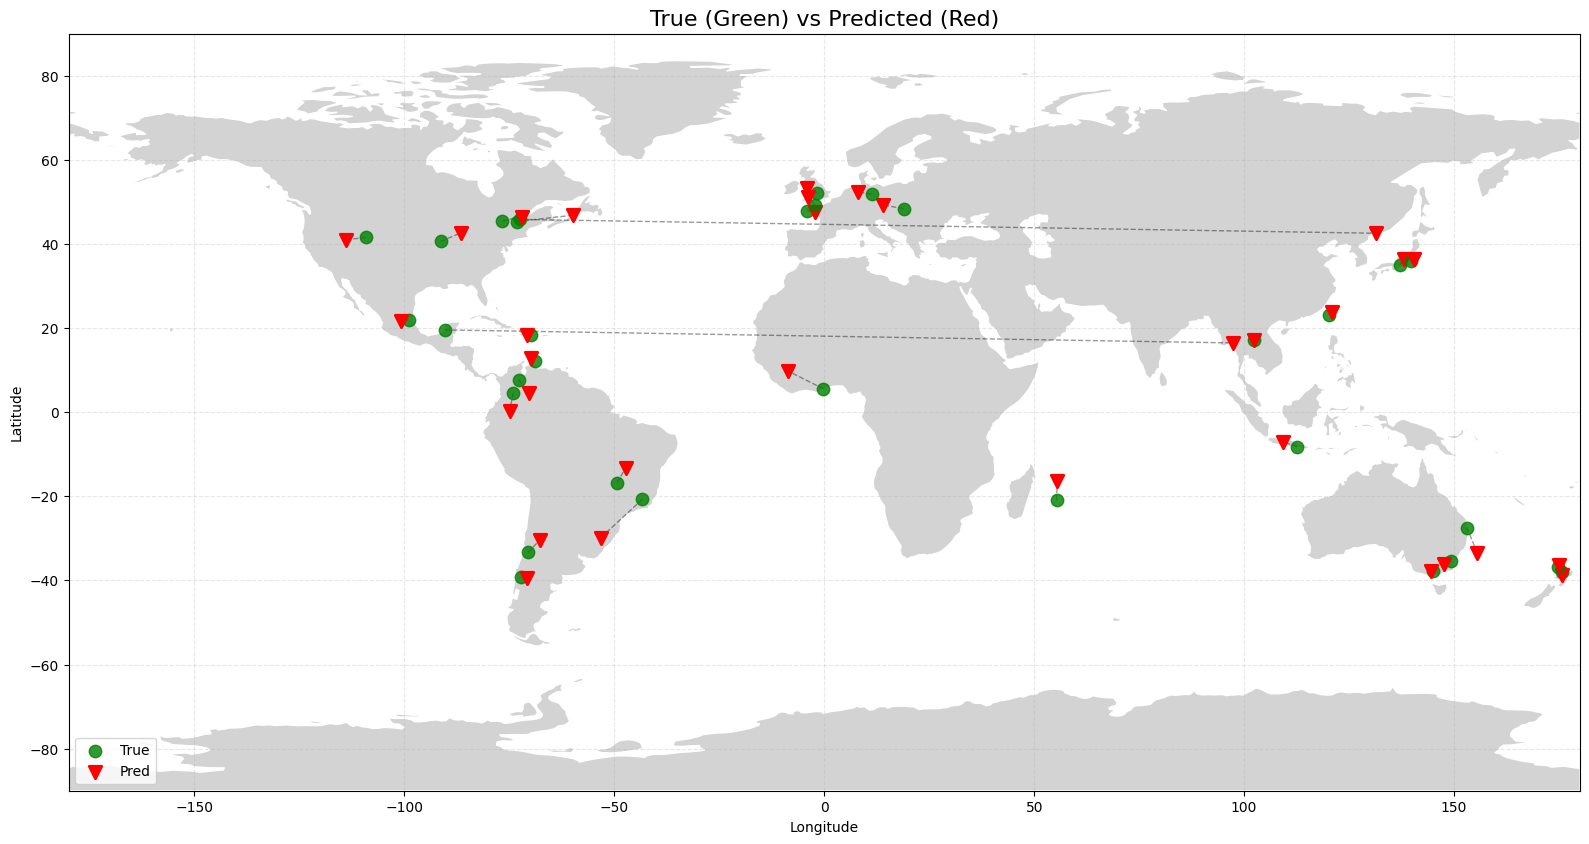

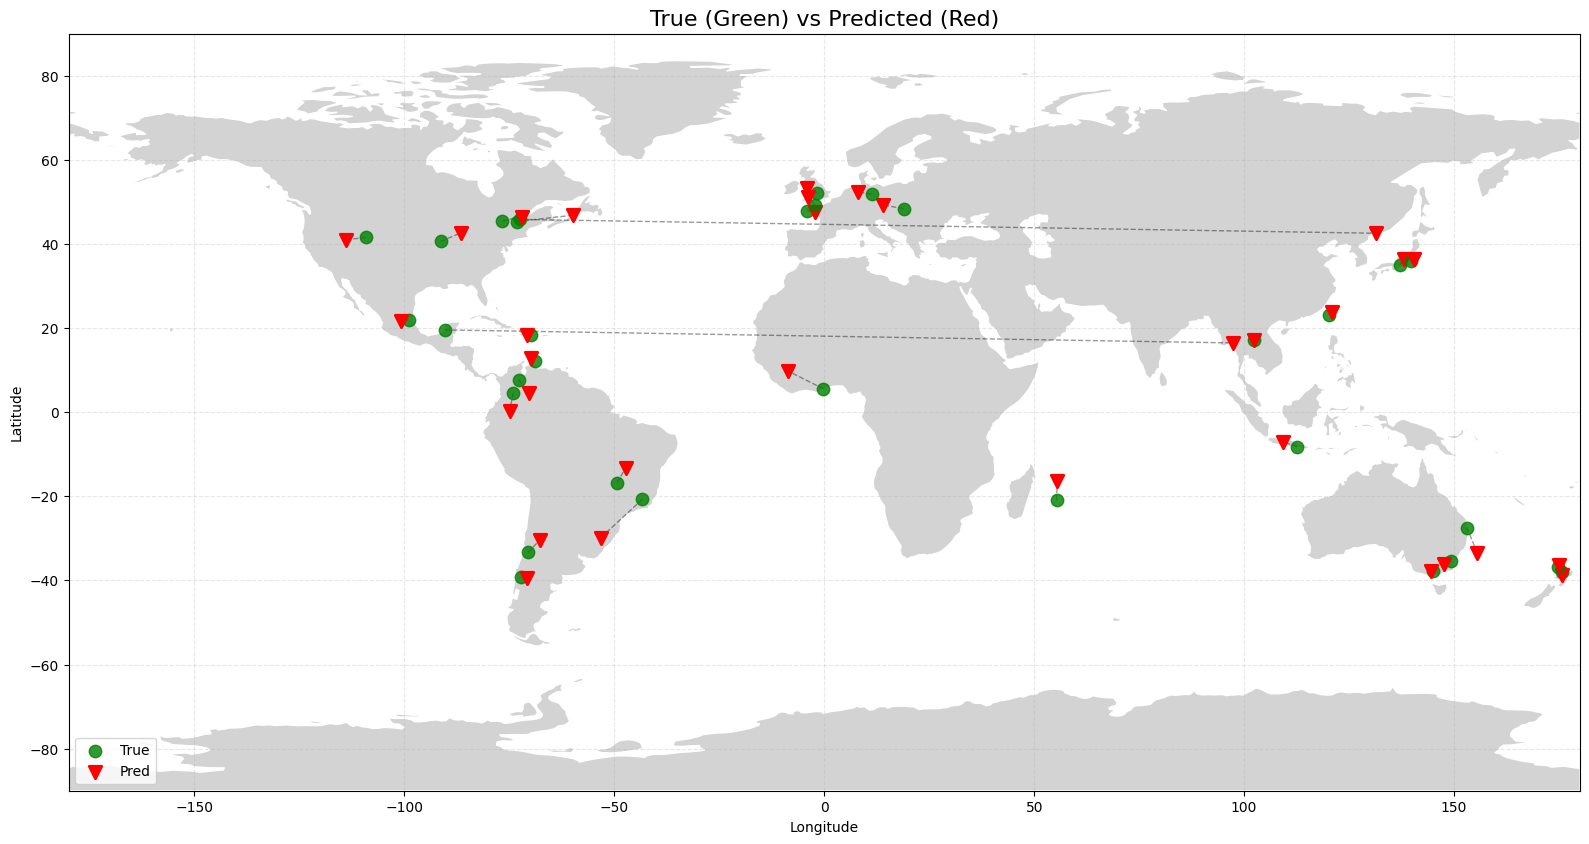

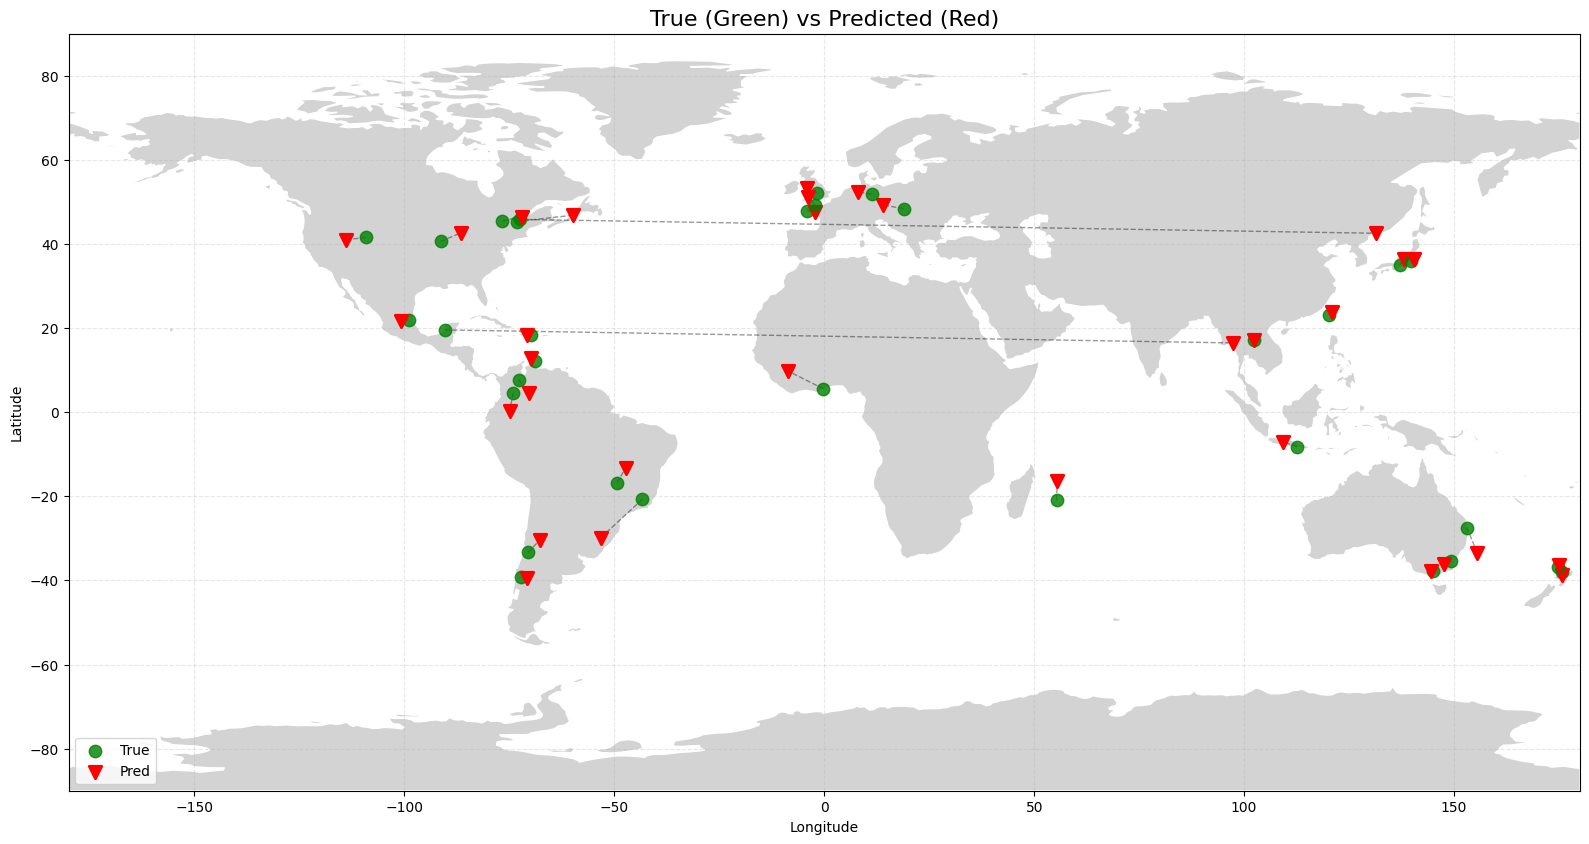

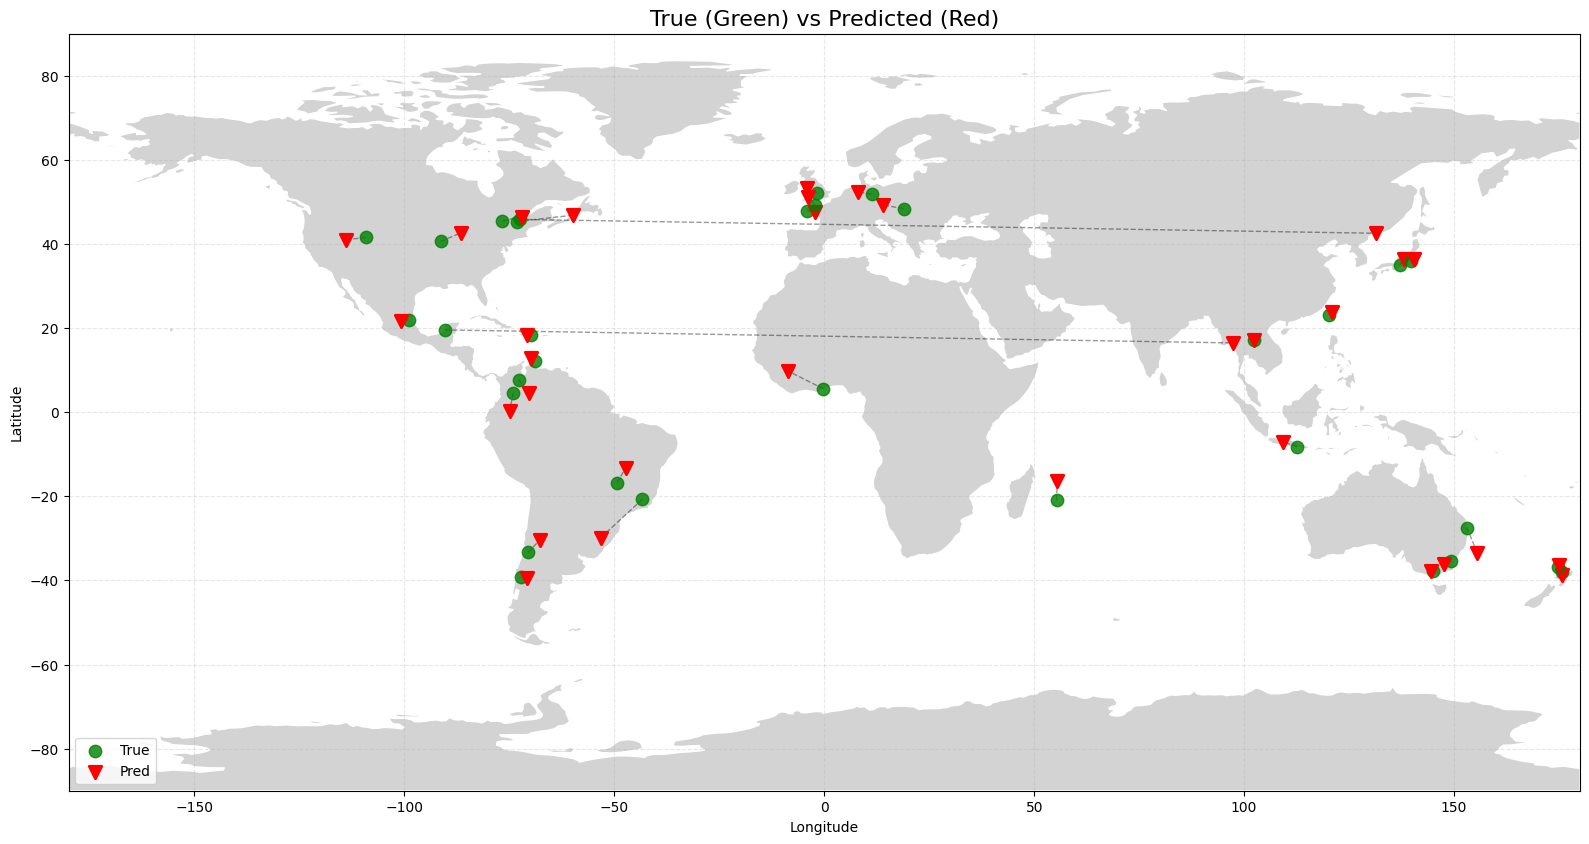

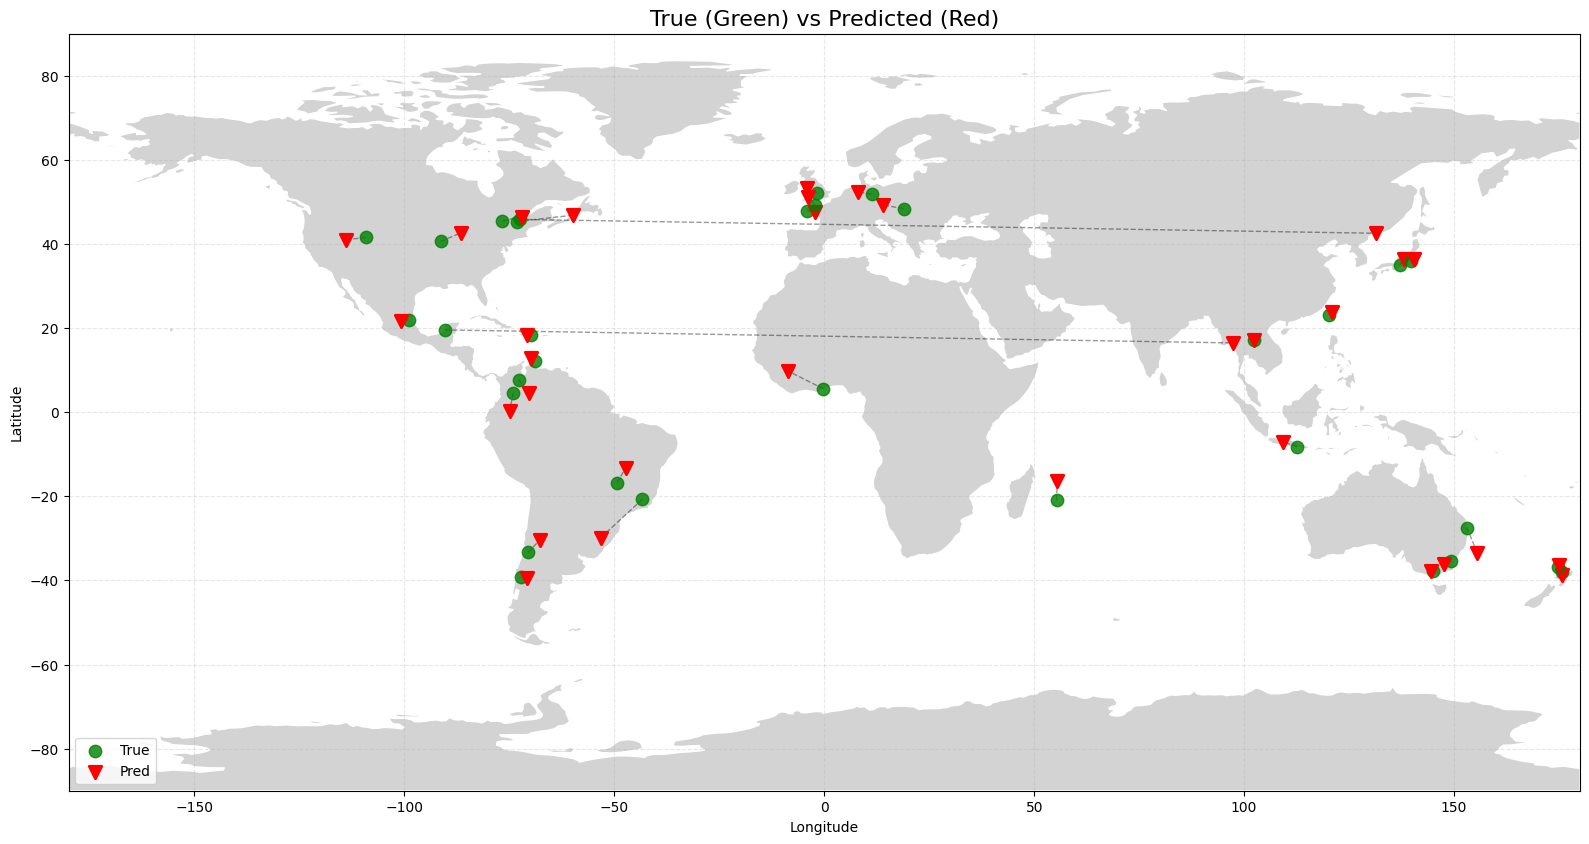

In [ ]:
import geopandas as gpd

def visualize_predictions(model, loader, device, num_batches):
    model.eval()


    for i in range(num_batches):
      imgs, (cont_labels, coord_labels) = next(iter(loader))
      imgs = imgs.to(device)
      coord_labels = coord_labels.to(device)

      with torch.inference_mode():

          logits, all_pred_coords = model(imgs)

          _, preds_continent = torch.max(logits, 1)

          batch_indices = torch.arange(imgs.size(0)).to(device)
          pred_coords = all_pred_coords[batch_indices, preds_continent]

      pred_coords = pred_coords.cpu().numpy()
      coord_labels = coord_labels.cpu().numpy()

      fig, ax = plt.subplots(figsize=(16, 9))
      try:
          path = geodatasets.get_path('naturalearth.land')
          world = gpd.read_file(path)
          world.plot(ax=ax, color='lightgray', edgecolor='white')
      except Exception as e:
          print(f"Map load warning: {e}")

      ax.set_xlim([-180, 180])
      ax.set_ylim([-90, 90])
      ax.set_title(f"True (Green) vs Predicted (Red)", fontsize=16)
      ax.set_xlabel("Longitude")
      ax.set_ylabel("Latitude")
      ax.grid(True, alpha=0.3, linestyle='--')

      for i in range(32):
          tx, ty, tz = coord_labels[i]
          tz = np.clip(tz, -1.0, 1.0)
          true_lat = np.degrees(np.arcsin(tz))
          true_lon = np.degrees(np.arctan2(ty, tx))

          px, py, pz = pred_coords[i]
          pz = np.clip(pz, -1.0, 1.0)
          pred_lat = np.degrees(np.arcsin(pz))
          pred_lon = np.degrees(np.arctan2(py, px))

          ax.scatter(true_lon, true_lat, c='green', marker='o', s=80, zorder=5, alpha=0.8, label='True' if i==0 else "")
          # ax.scatter(pred_lon, pred_lat, marker="📍", s=200, zorder=6, label='Pred' if i==0 else "")
          ax.scatter(pred_lon, pred_lat, c='red', marker='v', s=80, zorder=5, linewidth=2, label='Pred' if i==0 else "")
          ax.plot([true_lon, pred_lon], [true_lat, pred_lat], 'k--', alpha=0.4, linewidth=1, zorder=4)

      plt.legend(loc='lower left')
      plt.tight_layout()
      plt.show()

visualize_predictions(model, val_loader, device, num_batches=10)

# Inference

Distance error: 306.89 km


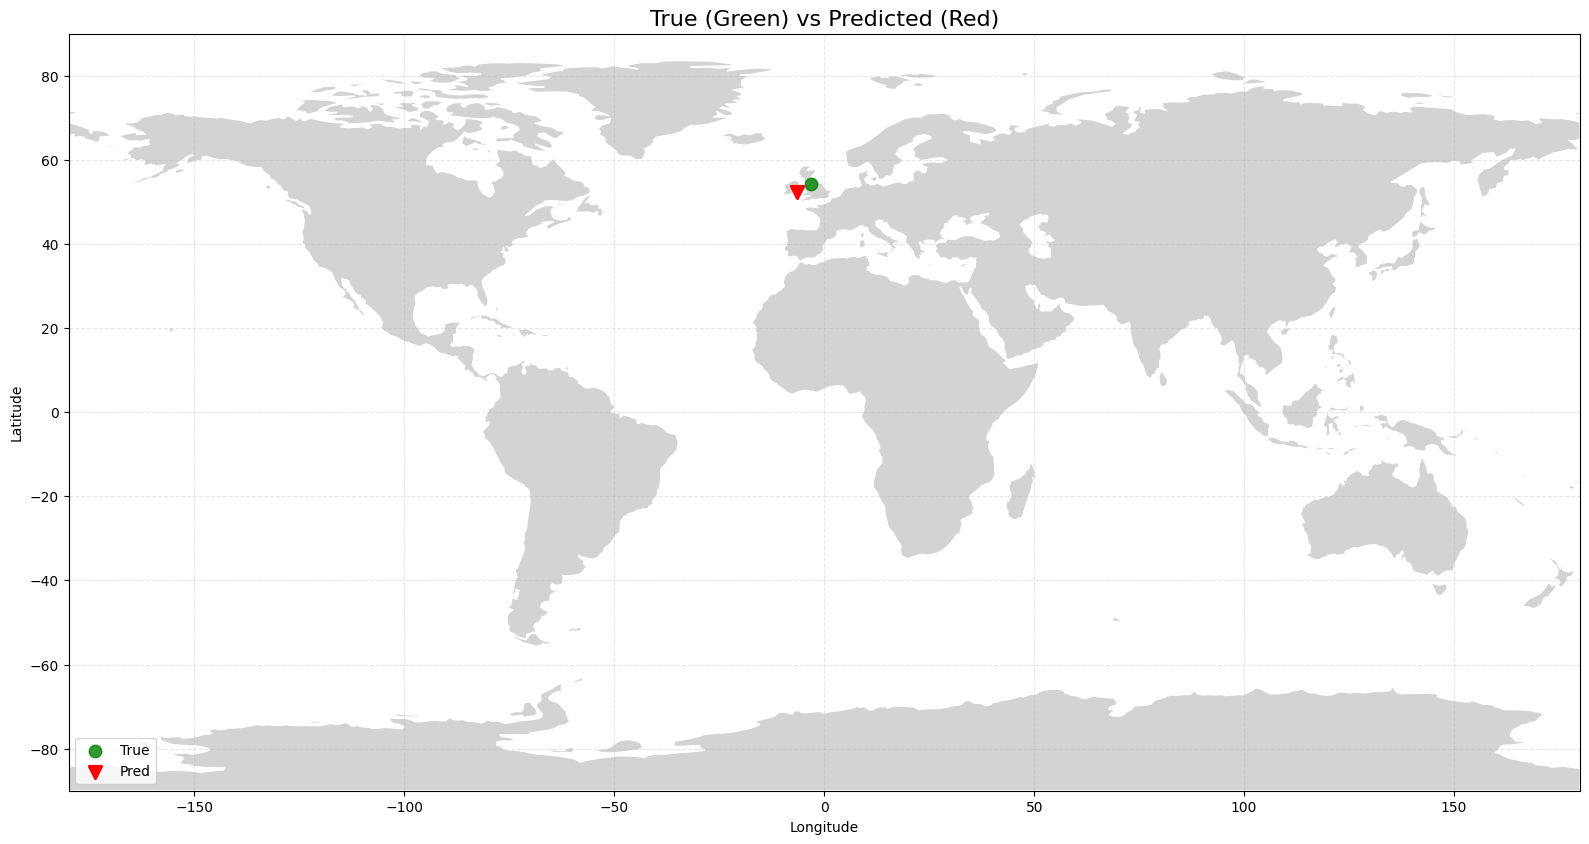

In [ ]:
def predict(model, image, true_coord_label, device):
  model.eval()

  # Stack images: [3, Channels, H, W]
  # And add a batch dimension for the model input (B, V, C, H, W) where B=1, V=3
  images_for_stack = [image, image, image]
  image_stack_for_model_input = torch.stack(images_for_stack).unsqueeze(0).to(device)

  with torch.inference_mode():
      continent_logits, all_pred_coords = model(image_stack_for_model_input)

      _, preds_continent = torch.max(continent_logits, 1)

      batch_indices = torch.arange(1).to(device) # Batch size is 1 for single inference
      # Extract the predicted coordinates for the predicted continent, and remove the batch dimension
      pred_coords = all_pred_coords[batch_indices, preds_continent].squeeze(0)

  pred_coords_np = pred_coords.cpu()
  true_coord_label_np = true_coord_label.cpu()

  fig, ax = plt.subplots(figsize=(16, 9))
  try:
      path = geodatasets.get_path('naturalearth.land')
      world = gpd.read_file(path)
      world.plot(ax=ax, color='lightgray', edgecolor='white')
  except Exception as e:
      print(f"Map load warning: {e}")

  ax.set_xlim([-180, 180])
  ax.set_ylim([-90, 90])
  ax.set_title(f"True (Green) vs Predicted (Red)", fontsize=16)
  ax.set_xlabel("Longitude")
  ax.set_ylabel("Latitude")
  ax.grid(True, alpha=0.3, linestyle='--')

  tx, ty, tz = true_coord_label_np
  tz = np.clip(tz, -1.0, 1.0)
  true_lat = np.degrees(np.arcsin(tz))
  true_lon = np.degrees(np.arctan2(ty, tx))

  px, py, pz = pred_coords_np
  pz = np.clip(pz, -1.0, 1.0)
  pred_lat = np.degrees(np.arcsin(pz))
  pred_lon = np.degrees(np.arctan2(py, px))

  ax.scatter(true_lon, true_lat, c='green', marker='o', s=80, zorder=5, alpha=0.8, label='True')
  ax.scatter(pred_lon, pred_lat, c='red', marker='v', s=80, zorder=5, linewidth=2, label='Pred')
  ax.plot([true_lon, pred_lon], [true_lat, pred_lat], 'k--', alpha=0.4, linewidth=1, zorder=4)

  # km_errors = geo_distance_km(pred_coords_np, true_coord_label_np)
  # print(km_errors)

  # Ensure batch dimension exists for distance calculation
  pred_coords_np = pred_coords_np.unsqueeze(0)
  true_coord_label_np = true_coord_label_np.unsqueeze(0)

  km_errors = geo_distance_km(pred_coords_np, true_coord_label_np)
  km_errors = km_errors.item()  # Convert tensor -> Python number
  print(f"Distance error: {km_errors:.2f} km")


  plt.legend(loc='lower left')
  plt.tight_layout()
  plt.show()



test_data = GeoguessrDataset(ROOT_DIR, split='test', transform=transform)

test_loader = DataLoader(test_data, batch_size=32, shuffle=True,
                          num_workers=os.cpu_count() or 2, pin_memory=True,
                          drop_last=True)

first_test_batch = next(iter(test_loader))

# Correctly unpack the batch and get a single image and its labels
batch_image_stacks, (batch_cont_labels, batch_coord_labels) = first_test_batch

# Get the first image from the first stack (as the predict function stacks it internally)
single_image_for_prediction = batch_image_stacks[0][0] # shape (C, H, W)

# Get the true coordinate label for the first sample in the batch
true_coord_label_for_prediction = batch_coord_labels[0] # shape (3,)

# Call the predict function with the single image and its true label
predict(model, single_image_for_prediction, true_coord_label_for_prediction, device)
